<a href="https://colab.research.google.com/github/eduardofmj97/EBAC/blob/main/Profissao_Cientista_de_Dados_M18_Pratique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [5]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [6]:
df.dtypes

,0
Valor_Aluguel,int64
Valor_Condominio,int64
Metragem,int64
N_Quartos,int64
N_banheiros,int64
N_Suites,int64
N_Vagas,int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


Tendo em vista que os valores iguais a 0 não são dados nulos uma vez que são referentes a valor de condomínio, número de vagas e número de suítes, não foram considerados pelas funções como nulos. Sendo assim, não há necessidade de tratamento nessa etapa.
Além disso, todas as colunas já estão no formato de inteiros.
Sendo assim, prosseguiremos para os próximos passos do tratamento.

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [8]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


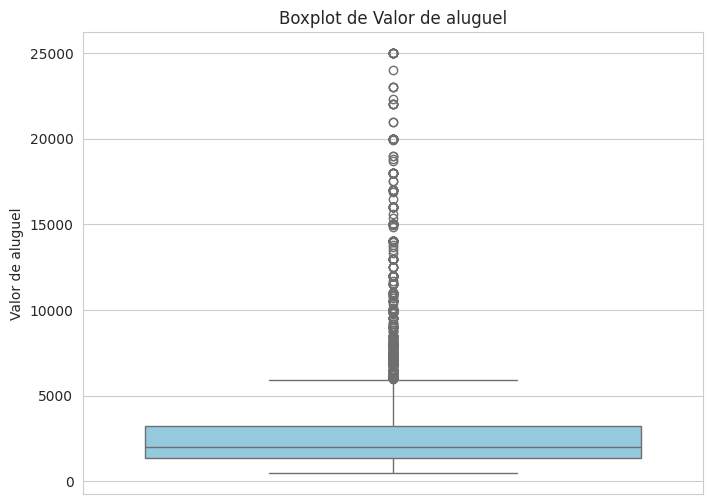

In [9]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Valor_Aluguel', color='skyblue')
plt.title('Boxplot de Valor de aluguel')
plt.ylabel('Valor de aluguel')
plt.show()

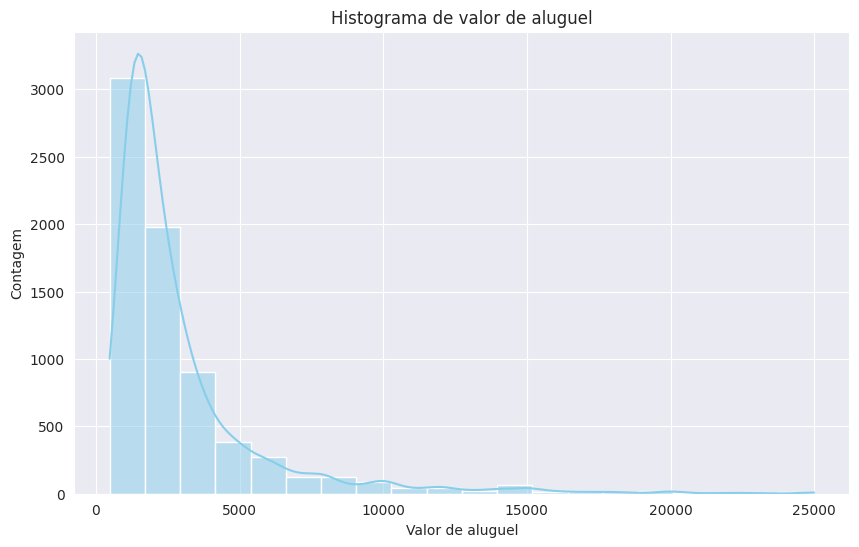

In [10]:
sns.set_style('darkgrid')
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Valor_Aluguel', bins=20, kde=True, color='skyblue')
plt.title('Histograma de valor de aluguel')
plt.xlabel('Valor de aluguel')
plt.ylabel('Contagem')
plt.show()

Podemos notar que nossa base de dados possui inúmeros outliers em relação ao valor de aluguel, demosntrando valores exorbitantes e possivelmente de imóveis que não são somente uma casa ou apartamento, mas sim sítios ou chácaras. Sendo assim, iremos tratar esses dados removendo todos que forem acima de 4500.

In [11]:
df = df[df['Valor_Aluguel'] <= 4500]

df.head()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


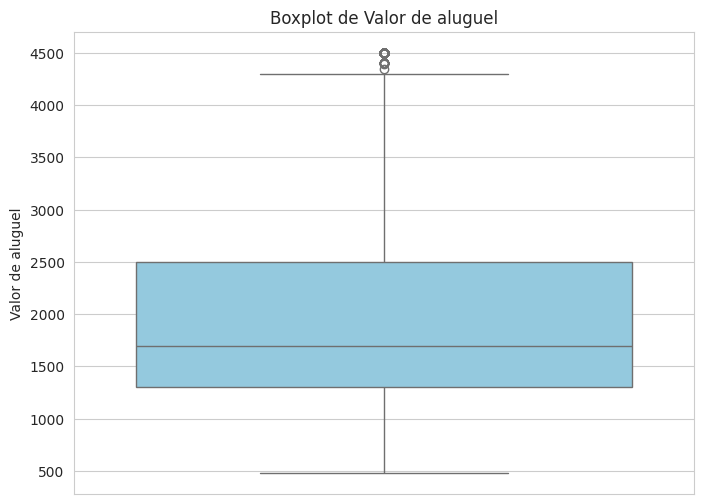

In [12]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Valor_Aluguel', color='skyblue')
plt.title('Boxplot de Valor de aluguel')
plt.ylabel('Valor de aluguel')
plt.show()

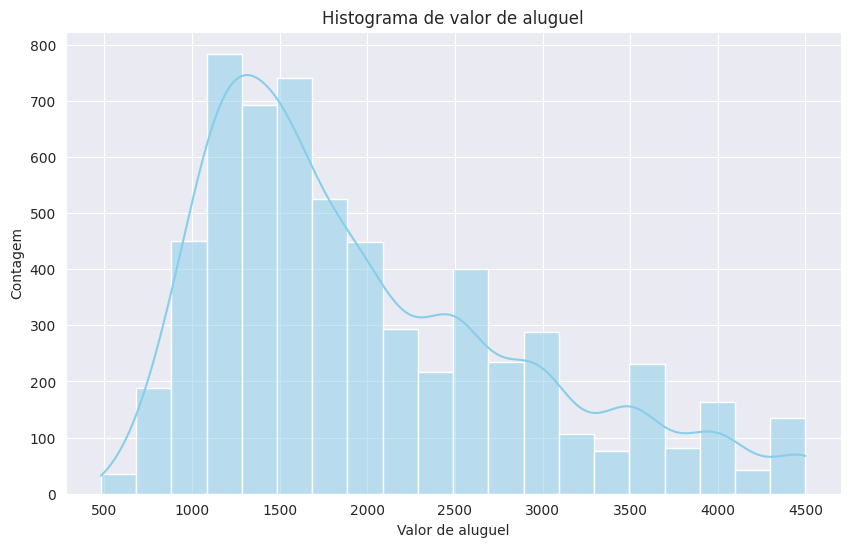

In [13]:
sns.set_style('darkgrid')
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Valor_Aluguel', bins=20, kde=True, color='skyblue')
plt.title('Histograma de valor de aluguel')
plt.xlabel('Valor de aluguel')
plt.ylabel('Contagem')
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6136 entries, 0 to 6135
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     6136 non-null   int64
 1   Valor_Condominio  6136 non-null   int64
 2   Metragem          6136 non-null   int64
 3   N_Quartos         6136 non-null   int64
 4   N_banheiros       6136 non-null   int64
 5   N_Suites          6136 non-null   int64
 6   N_Vagas           6136 non-null   int64
dtypes: int64(7)
memory usage: 383.5 KB


Agora, com os dados removidos, temos uma variação menor de acordo com o gráfico. O boxplot ainda demonstra a presença de alguns outliers, porém no histograma podemos notar que poucos imóveis tem os valores mais altos, mas ainda assim é uma quantidade que pode ser significativa nas futuras análises desse modelo.

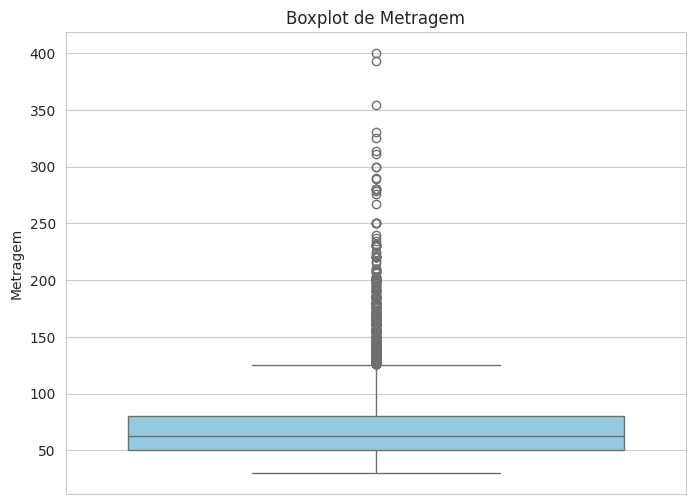

In [15]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Metragem', color='skyblue')
plt.title('Boxplot de Metragem')
plt.ylabel('Metragem')
plt.show()

Podemos notar que há alguns outliers ainda em relação à Metragem dos imóveis. Seguindo a mesma linha de pensamento que utilizamos para remover valores de aluguéis muito altos, seguiremos agora para a remoção de imóveis onde a metragem é igual ou acima de 100 m², visto que possivelmente não são somente casas, mas sítios ou chácaras.

In [16]:
df = df[df['Metragem'] <= 100]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5279 entries, 0 to 6135
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     5279 non-null   int64
 1   Valor_Condominio  5279 non-null   int64
 2   Metragem          5279 non-null   int64
 3   N_Quartos         5279 non-null   int64
 4   N_banheiros       5279 non-null   int64
 5   N_Suites          5279 non-null   int64
 6   N_Vagas           5279 non-null   int64
dtypes: int64(7)
memory usage: 329.9 KB


In [17]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,5279.000000,5279.000000,5279.000000,5279.000000,5279.000000,5279.000000,5279.000000
mean,1806.591021,504.534571,60.876871,2.031256,1.724758,0.701648,1.111953
std,776.131012,310.835160,15.842417,0.658958,0.504071,0.482568,0.462057
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.000000
25%,1200.000000,340.000000,50.000000,2.000000,1.000000,0.000000,1.000000
50%,1600.000000,500.000000,60.000000,2.000000,2.000000,1.000000,1.000000
75%,2200.000000,662.000000,70.000000,2.000000,2.000000,1.000000,1.000000
max,4500.000000,6059.000000,100.000000,4.000000,4.000000,3.000000,3.000000


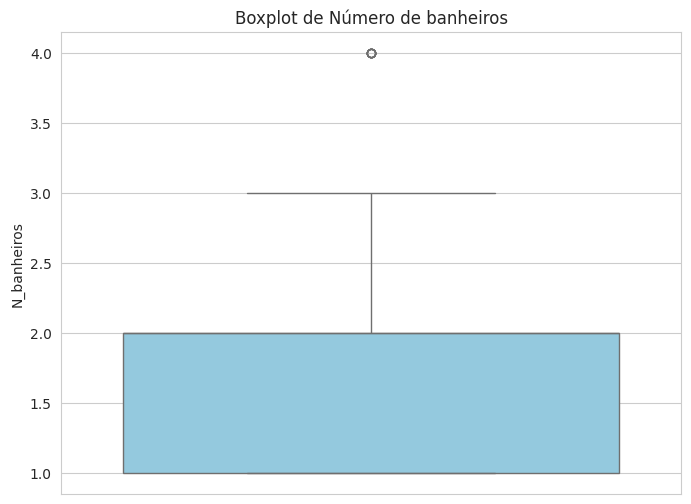

In [18]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='N_banheiros', color='skyblue')
plt.title('Boxplot de Número de banheiros')
plt.ylabel('N_banheiros')
plt.show()

Podemos também remover imóveis com mais de 3 banheiros, visto que claramente há outliers nessa análise.

In [19]:
df = df[df['N_banheiros'] <= 3]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5272 entries, 0 to 6135
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     5272 non-null   int64
 1   Valor_Condominio  5272 non-null   int64
 2   Metragem          5272 non-null   int64
 3   N_Quartos         5272 non-null   int64
 4   N_banheiros       5272 non-null   int64
 5   N_Suites          5272 non-null   int64
 6   N_Vagas           5272 non-null   int64
dtypes: int64(7)
memory usage: 329.5 KB


Podemos levar em consideração também os imóveis com grande número de suítes e vagas.

In [20]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,5272.000000,5272.000000,5272.000000,5272.000000,5272.000000,5272.000000,5272.000000
mean,1805.091806,503.849203,60.835357,2.030349,1.721737,0.700303,1.110774
std,775.056786,310.315913,15.807975,0.658719,0.497535,0.480403,0.460405
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.000000
25%,1200.000000,340.000000,50.000000,2.000000,1.000000,0.000000,1.000000
50%,1600.000000,500.000000,60.000000,2.000000,2.000000,1.000000,1.000000
75%,2200.000000,660.000000,70.000000,2.000000,2.000000,1.000000,1.000000
max,4500.000000,6059.000000,100.000000,4.000000,3.000000,2.000000,3.000000


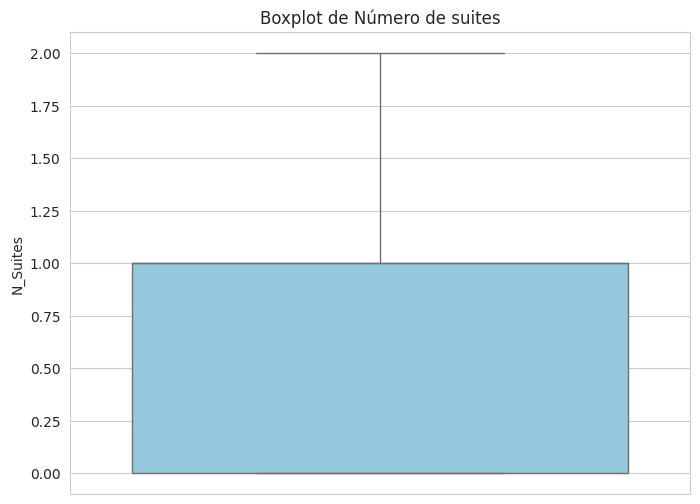

In [21]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='N_Suites', color='skyblue')
plt.title('Boxplot de Número de suites')
plt.ylabel('N_Suites')
plt.show()

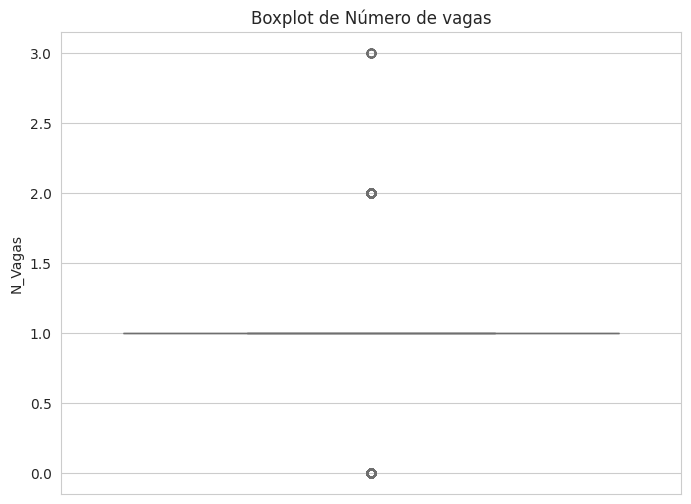

In [22]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='N_Vagas', color='skyblue')
plt.title('Boxplot de Número de vagas')
plt.ylabel('N_Vagas')
plt.show()

In [23]:
df = df[df['N_Vagas'] <= 2]
df = df[df['N_Suites'] <= 2]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5242 entries, 0 to 6135
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     5242 non-null   int64
 1   Valor_Condominio  5242 non-null   int64
 2   Metragem          5242 non-null   int64
 3   N_Quartos         5242 non-null   int64
 4   N_banheiros       5242 non-null   int64
 5   N_Suites          5242 non-null   int64
 6   N_Vagas           5242 non-null   int64
dtypes: int64(7)
memory usage: 327.6 KB


In [24]:
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,5242.000000,5242.000000,5242.000000,5242.000000,5242.000000,5242.000000,5242.000000
mean,1803.816101,501.088897,60.655475,2.025563,1.719763,0.698588,1.099962
std,775.801263,308.505534,15.654090,0.656753,0.497913,0.481239,0.438906
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.000000
25%,1200.000000,340.000000,50.000000,2.000000,1.000000,0.000000,1.000000
50%,1600.000000,500.000000,60.000000,2.000000,2.000000,1.000000,1.000000
75%,2200.000000,657.750000,70.000000,2.000000,2.000000,1.000000,1.000000
max,4500.000000,6059.000000,100.000000,4.000000,3.000000,2.000000,2.000000


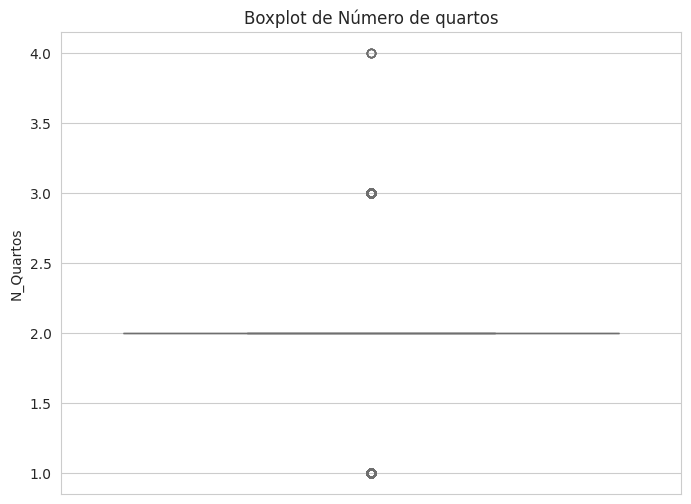

In [25]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='N_Quartos', color='skyblue')
plt.title('Boxplot de Número de quartos')
plt.ylabel('N_Quartos')
plt.show()

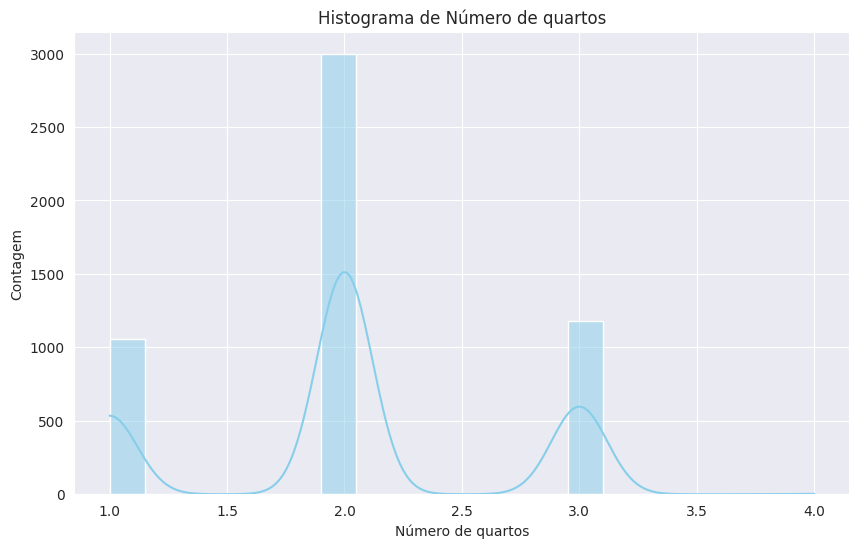

In [26]:
sns.set_style('darkgrid')
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='N_Quartos', bins=20, kde=True, color='skyblue')
plt.title('Histograma de Número de quartos')
plt.xlabel('Número de quartos')
plt.ylabel('Contagem')
plt.show()

Podemos também remover os imóveis com mais de 3 quartos, visto que é uma quantidade insignificante.

In [27]:
df = df[df['N_Quartos'] <= 3]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5236 entries, 0 to 6135
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     5236 non-null   int64
 1   Valor_Condominio  5236 non-null   int64
 2   Metragem          5236 non-null   int64
 3   N_Quartos         5236 non-null   int64
 4   N_banheiros       5236 non-null   int64
 5   N_Suites          5236 non-null   int64
 6   N_Vagas           5236 non-null   int64
dtypes: int64(7)
memory usage: 327.2 KB


Agora, após a limpeza de outliers dos dados, teremos uma base mais concisa e poderemos prosseguir para as análises bivariadas da nossa base para podermos ter insights em relação aos próximos estudos.

In [28]:
fig1 = px.scatter(df, x='Valor_Aluguel', y='Metragem', color="Valor_Aluguel",
                  size='Valor_Aluguel', hover_data=['Metragem'])

fig1.update_layout(title='Correlação entre Valor do aluguel e Metragem',
                  xaxis_title='Valor_Aluguel',
                  yaxis_title='Contagem',
                  legend_title='Metragem')

fig1.show()

Há uma boa distribuição na dispersão de dados quando analisamos o valor de aluguel de acordo com a metragem do imóvel. Logicamente, são dois valores que devem andar juntos, o que podemos confirmar através da visualização do gráfico de dispersão.

In [29]:
fig2 = px.histogram(df, x='Valor_Aluguel', color='N_Vagas', barmode='stack', text_auto=True)

fig2.update_layout(title='Correlação entre Valor de Aluguel and Número de vagas',
                  xaxis_title='Valor de Aluguel',
                  yaxis_title='Contagem',
                  legend_title='Número de vagas')

fig2.show()

Há uma boa distribuição dos dados uma vez que imóveis mais caros tendem a possuir vagas, sendo 1 ou 2.

In [30]:
fig3 = px.histogram(df, x='Valor_Aluguel', color='N_Quartos', barmode='stack', text_auto=True)

fig3.update_layout(title='Correlação entre Valor de Aluguel and Número de quartos',
                  xaxis_title='Valor de Aluguel',
                  yaxis_title='Contagem',
                  legend_title='Número de quartos')

fig3.show()

O número de quartos de acordo com o valor de aluguel também segue a mesma lógica das vagas na distribuição.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




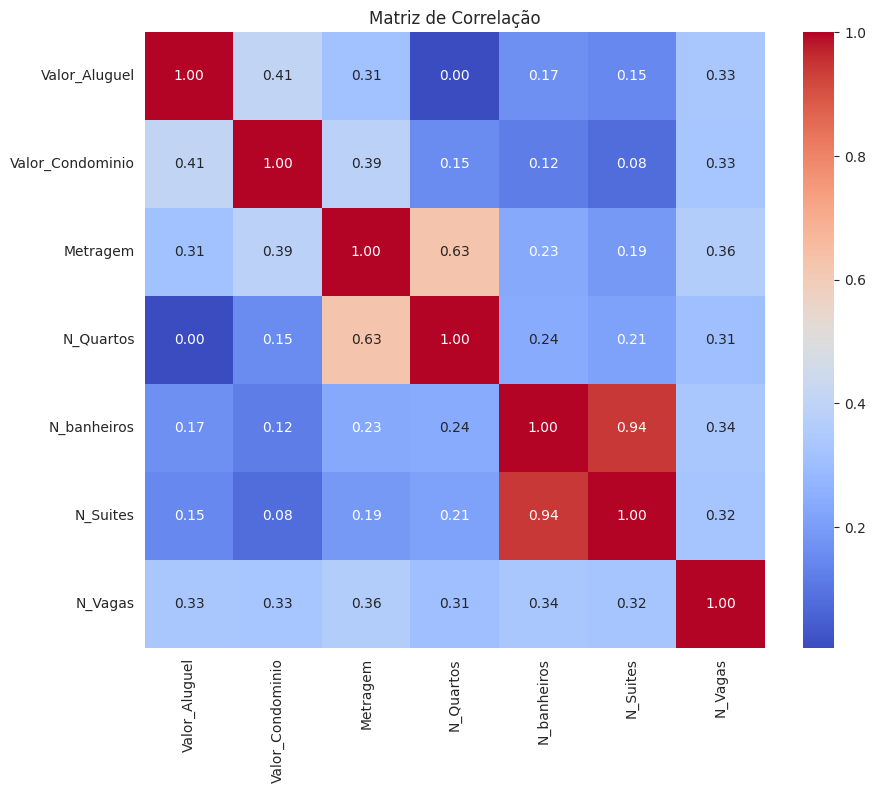

Correlação com o Valor_Aluguel:
Valor_Aluguel       1.000000
Valor_Condominio    0.405339
N_Vagas             0.331672
Metragem            0.314256
N_banheiros         0.165461
N_Suites            0.147058
N_Quartos           0.003800
Name: Valor_Aluguel, dtype: float64


In [31]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

print("Correlação com o Valor_Aluguel:")
print(correlation_matrix['Valor_Aluguel'].sort_values(ascending=False))


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [32]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [34]:
X = X_train[['Metragem']]  # Variável independente (características)
y = y_train  # Variável dependente (rótulo)

In [42]:
regressao_metragem = LinearRegression()
regressao_metragem.fit(X,y)

LinearRegression()

B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [50]:
print(f'coeficiente angular: {regressao_metragem.intercept_:.2f}')
print(f'coeficiente linear: {regressao_metragem.coef_[0]:.2f}')

coeficiente angular: 869.25
coeficiente linear: 15.39


Nossa equação seria:  

In [47]:
print(f'Nossa equação seria: {regressao_metragem.intercept_:.2f}*(X) + {regressao_metragem.coef_[0]:.2f}')

Nossa equação seria: 869.25*(X) + 15.39


c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [51]:
r_squared_train = regressao_metragem.score(X, y)
print(f'R-quadrado para o modelo de treinamento: {r_squared_train:.2f}')

R-quadrado para o modelo de treinamento: 0.10


O resultado não é bom, porém, pela análise que foi realizada, é compreensível o valor ter sido baixo.
A Regressão Linear realizada teve o intuito de prever o valor do aluguel do imóvel baseado na metragem, porém são duas variáveis que não possuem correlação forte entre si, como demonstrado na matriz de correlação. O nosso R² ter sido baixo demonstra que o modelo não é capaz de prever de forma eficiente o valor do aluguel com base somente na metragem do imóvel.

D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

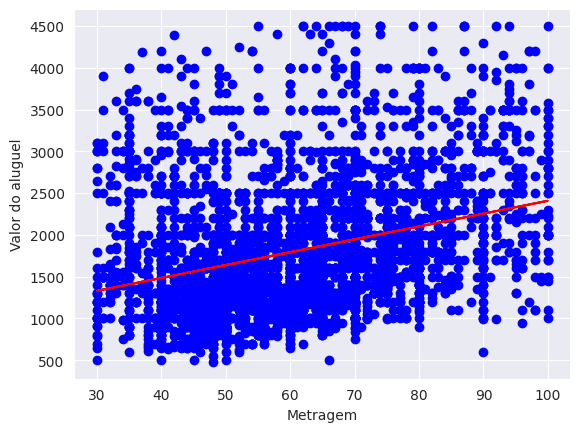

In [53]:
plt.scatter(X, y, color='blue', label='Dados originais')
plt.plot(X, regressao_metragem.predict(X), color='red', label='Regressão Linear')
plt.xlabel('Metragem')
plt.ylabel('Valor do aluguel')
plt.show()

Como podemos ver agora, claramente a dispersão dos dados é grande demais para que o modelo possa ser ajustado de forma eficaz, o que justifica o valor baixo de R². A variação dos dados em relação a reta nos traz uma grande margem de erro para realizar previsões.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [56]:
X_test = X_test[['Metragem']]  # Variável independente (características)
y_test = y_test  # Variável dependente (rótulo)

In [57]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = regressao_metragem.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao_metragem.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.10984306121134857


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

O valor do R² entre treino e teste é muito próximo, apresentando uma diferença de somente 0.009 entre si. Podemos considerar que o modelo é bem ajustado uma vez que existe essa proximidade, porém, por ambos os R² serem baixos, o modelo em si não é eficaz uma vez que a escolha de variáveis que não possuem correlação grande entre si compromete seu desempenho.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [63]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [64]:
regressao_multipla = LinearRegression()
regressao_multipla.fit(X_train, y_train)

LinearRegression()

C) Traga o valor do R quadrado e avalie o valor encontrado.

In [65]:
r_squared_train = regressao_multipla.score(X, y)
print(f'R-quadrado para o modelo de treinamento: {r_squared_train:.2f}')

R-quadrado para o modelo de treinamento: 0.28


O modelo indica que aproximadamente 28% da variação da variável dependente é explicado pela variação das variáveis independentes incluídas no modelo. É um resultado bem baixo para um modelo de previsão, o que pode ser explicado pela utilização de variáveis independentes que não apresentam grande correlação com a variável dependente ou então que existem variáveis externas que não foram incluídas no modelo, como bairro de localização do imóvel, segurança pública ou demais fatores.

D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [66]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = regressao_multipla.predict(X_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao_multipla.score(X_test, y_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.2844984532096696


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

O R² da regressão múltipla é bem maior uma vez que leva, nesse caso, a totalidade das variáveis independentes em consideração para gerar a previsão, se utilizando da correlação entre elas e a variável dependente, demonstrando uma maior acurácia do que a regressão linear simples, com R² de 0.109.
Na Regressão simples, escolhemos somente uma das variáveis dos dados para realizar a previsão, o que ocasiona em nem sempre escolhermos a variável que melhor se adequa ao dado que queremos prever.